# Hendel ICL accuracy + rank, with output→input head ablation

Measures full-prompt ICL accuracy and answer rank for every input-side and output-side condition, under three head-ablation states:
- **Unablated** (baseline)
- **Top 10% output→input heads ablated** (treatment)
- **Random 10% heads ablated** (control)

Heads are scored by *average* output-token attention to within-demo input positions across all 50 Hendel prompts per task (1000 prompts total).

Conditions:
- Input-side: orig, shuffled, wrong_task_inputs, random_from_input_pool, mean_embed, star, query_only
- Output-side: shuffled_outputs, wrong_task_outputs, random_from_output_pool, mean_embed_outputs, star_outputs (orig and query_only shared with input-side)

In [1]:
import os 
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
import sys; sys.path.insert(0, '../..')
import torch, numpy as np, matplotlib.pyplot as plt, pickle, random, seaborn as sns
import pandas as pd
from collections import defaultdict
from tqdm import tqdm
from math import sqrt
from transformer_lens import HookedTransformer
from configs import *
from utils import *
%matplotlib inline

sns.set_context('notebook')

model = HookedTransformer.from_pretrained(MODEL_NAME, device='cuda', dtype=torch.float16)
model.eval()
n_layers = model.cfg.n_layers
n_heads  = model.cfg.n_heads

with open('../../configs/splits.pkl', 'rb') as f:
    all_splits = pickle.load(f)

rng = random.Random(42)

/home/cvllab/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-25 10:21:39.584867: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  3.10it/s]


Loaded pretrained model meta-llama/Llama-3.2-3B into HookedTransformer


## Build pools and donor mappings

In [2]:
W_E = model.W_E.detach()

input_pool_all = []
input_pool_all_tokids = []
for task_name, splits in all_splits.items():
    for pdata in splits['icl_prompts']:
        for inp, _ in pdata['demo_pairs']:
            input_pool_all.append(inp)
            toks = model.to_tokens(' ' + inp, prepend_bos=False)[0]
            input_pool_all_tokids.append(toks[0].item())
mean_input_embed = W_E[input_pool_all_tokids].mean(dim=0)

output_pool_all = []
output_pool_all_tokids = []
for task_name, splits in all_splits.items():
    for pdata in splits['icl_prompts']:
        for _, out in pdata['demo_pairs']:
            output_pool_all.append(out)
            toks = model.to_tokens(' ' + out, prepend_bos=False)[0]
            output_pool_all_tokids.append(toks[0].item())
mean_output_embed = W_E[output_pool_all_tokids].mean(dim=0)

task_list = sorted(all_splits.keys())
donor_task = {t: task_list[(i + len(task_list) // 2) % len(task_list)]
              for i, t in enumerate(task_list)}

print(f'Input pool: {len(input_pool_all)}, Output pool: {len(output_pool_all)}')

Input pool: 10000, Output pool: 10000


## Score output→input heads (average-output method, all 50 prompts/task)

In [3]:
# Score: avg attention from output queries to within-demo input keys, MINUS avg attention from
# any non-output query position to any input key. Heads that selectively route output→input
# score high; heads that broadly attend to inputs from any query position score near zero.
oi_num_sum = np.zeros((n_layers, n_heads), dtype=np.float64)
oi_baseline_sum = np.zeros((n_layers, n_heads), dtype=np.float64)
oi_score_cnt = 0
PATTERN_FILTER = lambda name: 'attn.hook_pattern' in name

scoring_jobs = [(t, splits, p_idx, pdata)
                for t, splits in all_splits.items()
                for p_idx, pdata in enumerate(splits['icl_prompts'])]

for t, splits, p_idx, pdata in tqdm(scoring_jobs, desc='Scoring heads'):
    demos = pdata['demo_pairs']
    tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
    seq_len = tokens.shape[1]
    per_demo = find_per_demo_positions(model, pdata['prompt'], demos)
    
    all_input_positions = set()
    all_output_positions = set()
    for d in per_demo:
        for p in d.get('input_positions', []):  all_input_positions.add(p)
        for p in d.get('output_positions', []): all_output_positions.add(p)
    
    # Build masks for numerator and baseline
    num_mask = torch.zeros(seq_len, seq_len)
    for d in per_demo:
        ins  = d.get('input_positions', [])
        outs = d.get('output_positions', [])
        for op in outs:
            for ip in ins:
                num_mask[op, ip] = 1.0
    
    base_mask = torch.zeros(seq_len, seq_len)
    all_inputs_list = sorted(all_input_positions)
    for q in range(seq_len):
        if q in all_output_positions: continue
        for ik in all_inputs_list:
            if ik <= q:
                base_mask[q, ik] = 1.0
    
    n_num_pairs  = int(num_mask.sum().item())
    n_base_pairs = int(base_mask.sum().item())
    if n_num_pairs == 0 or n_base_pairs == 0: continue
    
    with torch.no_grad():
        _, cache = model.run_with_cache(tokens, names_filter=PATTERN_FILTER)
    
    for L in range(n_layers):
        patt = cache['pattern', L][0].cpu().float()  # [n_heads, seq, seq]
        num_per_head  = (patt * num_mask).sum(dim=(1, 2)).numpy() / n_num_pairs
        base_per_head = (patt * base_mask).sum(dim=(1, 2)).numpy() / n_base_pairs
        oi_num_sum[L, :]      += num_per_head
        oi_baseline_sum[L, :] += base_per_head
    
    oi_score_cnt += 1
    del cache
    torch.cuda.empty_cache()

oi_num      = oi_num_sum      / max(oi_score_cnt, 1)
oi_baseline = oi_baseline_sum / max(oi_score_cnt, 1)
oi_score    = oi_num - oi_baseline

flat = [(L, h, oi_score[L, h]) for L in range(n_layers) for h in range(n_heads)]
flat.sort(key=lambda x: -x[2])
top10pct_n = max(1, int(0.10 * len(flat)))
top10_heads = [(L, h) for L, h, s in flat[:top10pct_n]]

_rng_h = random.Random(0)
all_pairs = [(L, h) for L in range(n_layers) for h in range(n_heads)]
top10_set = set(top10_heads)
rand10_heads = _rng_h.sample([p for p in all_pairs if p not in top10_set], top10pct_n)

print(f'\nScored {oi_score_cnt} prompts')
print(f'Top 10 heads by selective output→input score:')
for L, h, s in flat[:10]:
    print(f'  L{L:2d}H{h:2d}: score={s:+.4f}  (output→input={oi_num[L,h]:.4f}, non-output→input baseline={oi_baseline[L,h]:.4f})')
print(f'\nWill ablate {top10pct_n} heads (top 10%) and matched random 10%')

Scoring heads: 100%|██████████| 1000/1000 [01:50<00:00,  9.07it/s]


Scored 1000 prompts
Top 10 heads by selective output→input score:
  L 5H 3: score=+0.1925  (output→input=0.2002, non-output→input baseline=0.0077)
  L10H10: score=+0.1554  (output→input=0.1700, non-output→input baseline=0.0147)
  L 4H14: score=+0.1369  (output→input=0.1407, non-output→input baseline=0.0038)
  L13H13: score=+0.1250  (output→input=0.1287, non-output→input baseline=0.0037)
  L 7H 7: score=+0.1177  (output→input=0.1296, non-output→input baseline=0.0119)
  L 7H18: score=+0.1059  (output→input=0.1254, non-output→input baseline=0.0195)
  L 8H 8: score=+0.1017  (output→input=0.1064, non-output→input baseline=0.0047)
  L 1H16: score=+0.0901  (output→input=0.0954, non-output→input baseline=0.0053)
  L13H12: score=+0.0893  (output→input=0.0974, non-output→input baseline=0.0081)
  L12H 1: score=+0.0890  (output→input=0.1072, non-output→input baseline=0.0182)

Will ablate 67 heads (top 10%) and matched random 10%


In [4]:
import pickle
with open('../results/hendel_top10_heads.pkl', 'wb') as f:
    pickle.dump({'top10': top10_heads, 'rand10': rand10_heads,
                 'oi_score': oi_score, 'flat': flat}, f)

## Ablation hook helpers

In [5]:
def heads_by_layer_from(head_list):
    d = defaultdict(list)
    for L, h in head_list:
        d[L].append(h)
    return d

def make_ablation_hooks(heads_by_layer):
    fwd_hooks = []
    for L, h_list in heads_by_layer.items():
        def hook(z, hook, _h_list=h_list):
            for h in _h_list:
                z[0, :, h, :] = 0
            return z
        fwd_hooks.append((f'blocks.{L}.attn.hook_z', hook))
    return fwd_hooks

def make_embed_hook(positions, replacement_vec):
    def hook_fn(emb, hook):
        for p in positions:
            emb[:, p, :] = replacement_vec.to(emb.dtype)
        return emb
    return hook_fn

ablation_hooks_top10  = make_ablation_hooks(heads_by_layer_from(top10_heads))
ablation_hooks_rand10 = make_ablation_hooks(heads_by_layer_from(rand10_heads))

## Average attention pattern of top heads (slot-aggregated)

To average attention patterns across prompts that have different tokenizations, define abstract slots and aggregate.

**Slot definition.** Each demo has three slots: `input`, `arrow`, `output`. Plus the BOS slot at the start and the query slots at the end (`query_input`, `query_arrow`). For a 10-demo prompt: `BOS` + 10 × (`input_d`, `arrow_d`, `output_d`) + `query_input` + `query_arrow` = 32 slots.

**Aggregation.** For each pair of slots (q_slot, k_slot), average the attention weight over all (q_pos, k_pos) pairs where q_pos is in q_slot and k_pos is in k_slot. This gives a fixed-shape `[n_slots, n_slots]` matrix per (prompt, layer, head). Average across prompts.

In [7]:
from collections import defaultdict as _defaultdict

n_demos_assumed = 10
slot_labels = ['BOS']
for d in range(n_demos_assumed):
    slot_labels += [f'in_{d}', f'arr_{d}', f'out_{d}']
slot_labels += ['q_in', 'q_arr']
n_slots = len(slot_labels)
slot_idx = {s: i for i, s in enumerate(slot_labels)}

def position_to_slot(pos, per_demo, seq_len):
    if pos == 0: return 'BOS'
    for d_idx, d in enumerate(per_demo):
        ins  = d.get('input_positions', [])
        outs = d.get('output_positions', [])
        if pos in ins:  return f'in_{d_idx}'
        if pos in outs: return f'out_{d_idx}'
        if ins and outs and (max(ins) < pos < min(outs)): return f'arr_{d_idx}'
    last_demo = per_demo[-1]
    last_out = max(last_demo.get('output_positions', [0]))
    if pos > last_out:
        if pos == seq_len - 1: return 'q_arr'
        return 'q_in'
    return None

TOP_N_TO_PLOT = 9
heads_to_plot = [(L, h) for L, h, s in flat[:TOP_N_TO_PLOT]]

agg_sum = {(L, h): np.zeros((n_slots, n_slots), dtype=np.float64) for L, h in heads_to_plot}
agg_cnt = {(L, h): np.zeros((n_slots, n_slots), dtype=np.int64) for L, h in heads_to_plot}

# Use all prompts
all_jobs_for_pattern = scoring_jobs

for t, splits, p_idx, pdata in tqdm(all_jobs_for_pattern, desc='Aggregating attention'):
    demos = pdata['demo_pairs']
    if len(demos) != n_demos_assumed: continue
    tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
    seq_len = tokens.shape[1]
    per_demo = find_per_demo_positions(model, pdata['prompt'], demos)
    
    # Build a per-position slot index array (or -1 if no slot assigned)
    pos_slot_arr = np.full(seq_len, -1, dtype=np.int64)
    for pos in range(seq_len):
        s = position_to_slot(pos, per_demo, seq_len)
        if s is not None:
            pos_slot_arr[pos] = slot_idx[s]
    
    valid = pos_slot_arr >= 0
    if not valid.any(): continue
    
    # Build a count matrix: how many (q, k) pairs fall into each (q_slot, k_slot) cell.
    # For q >= k (causal), q_slot = pos_slot_arr[q], k_slot = pos_slot_arr[k].
    q_idx, k_idx = np.meshgrid(np.arange(seq_len), np.arange(seq_len), indexing='ij')
    causal_mask = (q_idx >= k_idx) & valid[q_idx] & valid[k_idx]
    q_slot_grid = np.where(causal_mask, pos_slot_arr[q_idx], -1)
    k_slot_grid = np.where(causal_mask, pos_slot_arr[k_idx], -1)
    
    # Flat indices for the slot grid
    flat_slot_idx = q_slot_grid * n_slots + k_slot_grid  # negative where invalid
    flat_valid = causal_mask
    
    # Count matrix per prompt
    counts_flat = np.bincount(flat_slot_idx[flat_valid], minlength=n_slots * n_slots)
    slot_cnt = counts_flat.reshape(n_slots, n_slots)
    
    with torch.no_grad():
        _, cache = model.run_with_cache(tokens, names_filter=PATTERN_FILTER)
    
    for L, h in heads_to_plot:
        patt = cache['pattern', L][0, h].cpu().float().numpy()  # [seq, seq]
        # Sum attention values into slot cells via bincount weighted by patt values
        sums_flat = np.bincount(
            flat_slot_idx[flat_valid],
            weights=patt[flat_valid],
            minlength=n_slots * n_slots,
        )
        slot_sum = sums_flat.reshape(n_slots, n_slots)
        with np.errstate(invalid='ignore', divide='ignore'):
            slot_avg = np.where(slot_cnt > 0, slot_sum / slot_cnt, 0.0)
        agg_sum[(L, h)] += slot_avg
        agg_cnt[(L, h)] += (slot_cnt > 0).astype(np.int64)
    
    del cache
    torch.cuda.empty_cache()

head_patterns = {}
for L, h in heads_to_plot:
    with np.errstate(invalid='ignore', divide='ignore'):
        head_patterns[(L, h)] = np.where(agg_cnt[(L, h)] > 0, agg_sum[(L, h)] / agg_cnt[(L, h)], 0.0)

print(f'Aggregated attention patterns for top {TOP_N_TO_PLOT} heads across {len(all_jobs_for_pattern)} prompts')

Aggregating attention: 100%|██████████| 1000/1000 [01:06<00:00, 14.99it/s]

Aggregated attention patterns for top 9 heads across 1000 prompts


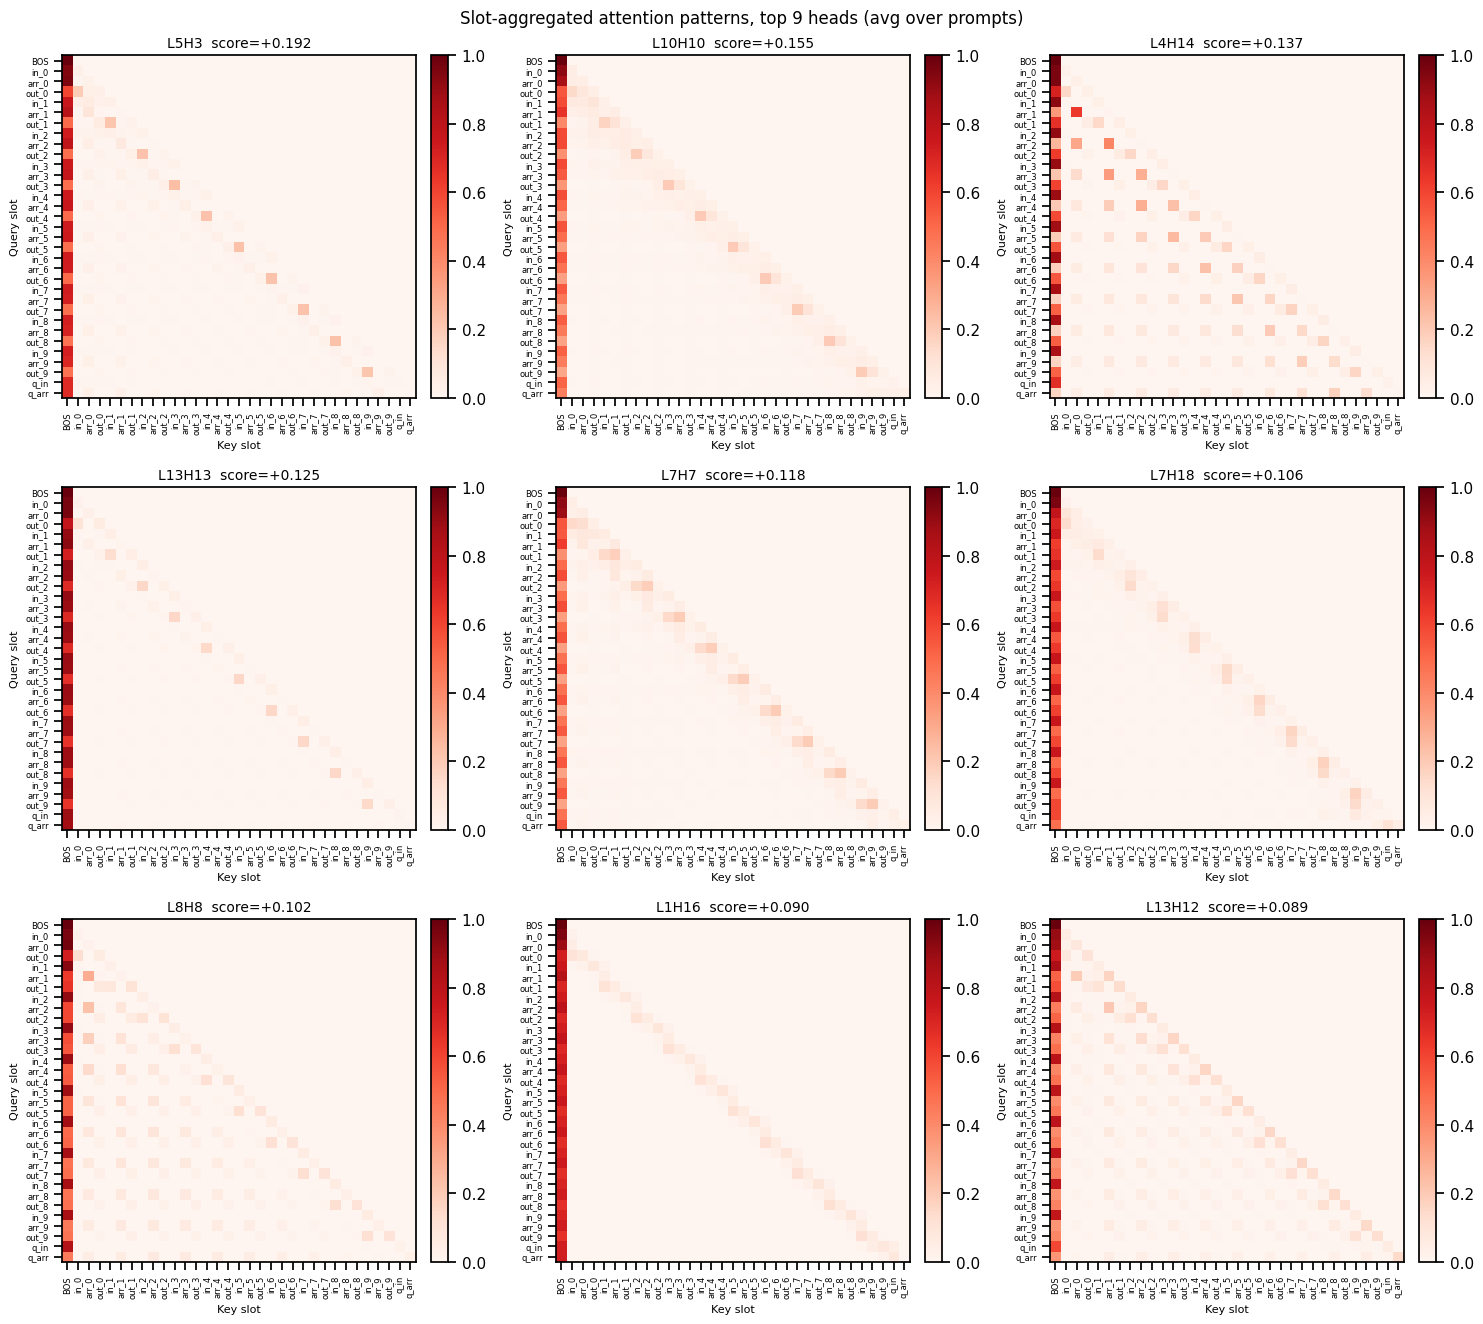

In [9]:
n_cols_p = 3
n_rows_p = int(np.ceil(len(heads_to_plot) / n_cols_p))
fig, axes = plt.subplots(n_rows_p, n_cols_p, figsize=(5*n_cols_p, 4.5*n_rows_p))
axes = axes.flatten()

for ax, (L, h) in zip(axes, heads_to_plot):
    pat = head_patterns[(L, h)]
    im = ax.imshow(pat, aspect='auto', cmap='Reds', origin='upper', vmin=0)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(f'L{L}H{h}  score={oi_score[L,h]:+.3f}', fontsize=10)
    ax.set_xticks(range(n_slots))
    ax.set_xticklabels(slot_labels, rotation=90, fontsize=6)
    ax.set_yticks(range(n_slots))
    ax.set_yticklabels(slot_labels, fontsize=6)
    ax.set_xlabel('Key slot', fontsize=8)
    ax.set_ylabel('Query slot', fontsize=8)

for ax in axes[len(heads_to_plot):]:
    ax.set_visible(False)

fig.suptitle(f'Slot-aggregated attention patterns, top {TOP_N_TO_PLOT} heads (avg over prompts)', fontsize=12)
plt.tight_layout(); plt.show()

## Build all condition prompts (input-side and output-side, 50/task)

Each prompt produces a `prompts_by_cond` dict for both sides. The accuracy/rank measurement loop reuses this so every ablation state sees the exact same prompt set.

In [10]:
CONDS_IN  = ['orig', 'shuffled', 'wrong_task_inputs', 'random_from_input_pool',
             'mean_embed', 'star', 'query_only']
CONDS_OUT = ['shuffled_outputs', 'wrong_task_outputs', 'random_from_output_pool',
             'mean_embed_outputs', 'star_outputs']
ALL_CONDS = CONDS_IN + CONDS_OUT  # 'orig' and 'query_only' are shared

all_jobs = [(task_name, splits, p_idx, pdata)
            for task_name, splits in all_splits.items()
            for p_idx, pdata in enumerate(splits['icl_prompts'])]

# Pre-build prompts and the per-prompt mean_embed positions, so the per-ablation passes don't redo this.
prebuilt = []  # list of dicts with prompts, tokens, positions, ans

for task_name, splits, p_idx, pdata in tqdm(all_jobs, desc='Building prompts'):
    demos = pdata['demo_pairs']
    qi = pdata['query_input']
    ans = pdata.get('query_output')
    if ans is None:
        prebuilt.append(None); continue
    
    inputs  = [i for i, _ in demos]
    outputs = [o for _, o in demos]
    
    inputs_shuffled  = inputs.copy();  rng.shuffle(inputs_shuffled)
    outputs_shuffled = outputs.copy(); rng.shuffle(outputs_shuffled)
    
    donor_prompts = all_splits[donor_task[task_name]]['icl_prompts']
    donor_pdata = donor_prompts[p_idx % len(donor_prompts)]
    inputs_wrong  = [i for i, _ in donor_pdata['demo_pairs']]
    outputs_wrong = [o for _, o in donor_pdata['demo_pairs']]
    if len(inputs_wrong) < len(demos):
        inputs_wrong  = (inputs_wrong  * ((len(demos) // len(inputs_wrong))  + 1))[:len(demos)]
        outputs_wrong = (outputs_wrong * ((len(demos) // len(outputs_wrong)) + 1))[:len(demos)]
    inputs_wrong  = inputs_wrong[:len(demos)]
    outputs_wrong = outputs_wrong[:len(demos)]
    
    inputs_random  = [rng.choice(input_pool_all)  for _ in inputs]
    outputs_random = [rng.choice(output_pool_all) for _ in outputs]
    
    prompts = {
        'orig':                     pdata['prompt'],
        'shuffled':                 build_icl_prompt(list(zip(inputs_shuffled, outputs)), qi),
        'wrong_task_inputs':        build_icl_prompt(list(zip(inputs_wrong,    outputs)), qi),
        'random_from_input_pool':   build_icl_prompt(list(zip(inputs_random,   outputs)), qi),
        'star':                     build_icl_prompt([('*', o) for o in outputs], qi),
        'query_only':               f'{qi} \u2192',
        'shuffled_outputs':         build_icl_prompt(list(zip(inputs, outputs_shuffled)), qi),
        'wrong_task_outputs':       build_icl_prompt(list(zip(inputs, outputs_wrong)),    qi),
        'random_from_output_pool':  build_icl_prompt(list(zip(inputs, outputs_random)),   qi),
        'star_outputs':             build_icl_prompt([(i, '*') for i in inputs], qi),
    }
    tokens = {k: model.to_tokens(v, prepend_bos=True) for k, v in prompts.items()}
    lasts  = {k: v.shape[1]-1 for k, v in tokens.items()}
    
    # mean_embed positions: input and output positions in orig prompt
    per_demo_orig = find_per_demo_positions(model, prompts['orig'], demos)
    input_positions  = [p for d in per_demo_orig for p in d.get('input_positions', [])]
    output_positions = [p for d in per_demo_orig for p in d.get('output_positions', [])]
    
    prebuilt.append({
        'task': task_name, 'p_idx': p_idx,
        'prompts': prompts, 'tokens': tokens, 'lasts': lasts, 'ans': ans,
        'input_positions': input_positions, 'output_positions': output_positions,
    })
    torch.cuda.empty_cache()

n_prompts_total = sum(1 for x in prebuilt if x is not None)
print(f'\nPrebuilt {n_prompts_total} prompts across {len(set(x["task"] for x in prebuilt if x is not None))} tasks')

Building prompts: 100%|██████████| 1000/1000 [00:50<00:00, 19.89it/s]


Prebuilt 1000 prompts across 20 tasks


## Compute accuracy and rank for each (condition, ablation) pair

Helper: `answer_rank` and `check_correct` from utils. For each condition, evaluate the ICL prompt with no hooks (unablated), then with top-10% hooks, then with random-10% hooks. The mean_embed conditions need an embedding hook composed with the ablation hooks.

In [12]:
def answer_rank(model, logits, answer):
    ans_tok = model.to_tokens(' ' + answer, prepend_bos=False)[0, 0].item()
    return int((logits > logits[ans_tok]).sum().item())

In [16]:
ABL_KEYS = ['unablated', 'top10', 'rand10']
ablation_hook_sets = {
    'unablated': [],
    'top10':  ablation_hooks_top10,
    'rand10': ablation_hooks_rand10,
}

results_correct = {ab: {c: [] for c in ALL_CONDS} for ab in ABL_KEYS}
results_rank    = {ab: {c: [] for c in ALL_CONDS} for ab in ABL_KEYS}
prompt_task_record = []

for entry in tqdm(prebuilt, desc='Eval (cond x ablation)'):
    if entry is None: continue
    prompts = entry['prompts']
    tokens  = entry['tokens']
    lasts   = entry['lasts']
    ans     = entry['ans']
    
    for ab_key, ab_hooks in ablation_hook_sets.items():
        for c in ALL_CONDS:
            extra_hooks = []
            
            if c == 'mean_embed':
                eh = ('hook_embed', make_embed_hook(entry['input_positions'], mean_input_embed))
                extra_hooks = [eh]
                target_tokens = tokens['orig']
                target_last   = lasts['orig']
            elif c == 'mean_embed_outputs':
                eh = ('hook_embed', make_embed_hook(entry['output_positions'], mean_output_embed))
                extra_hooks = [eh]
                target_tokens = tokens['orig']
                target_last   = lasts['orig']
            else:
                target_tokens = tokens[c]
                target_last   = lasts[c]
            
            combined = list(ab_hooks) + extra_hooks
            with torch.no_grad():
                if combined:
                    logits = model.run_with_hooks(target_tokens, fwd_hooks=combined)[0, target_last]
                else:
                    logits = model(target_tokens)[0, target_last]
            
            results_correct[ab_key][c].append(int(check_correct(model, logits, ans)))
            results_rank[ab_key][c].append(answer_rank(model, logits, ans))
    
    prompt_task_record.append(entry['task'])
    torch.cuda.empty_cache()

for ab in ABL_KEYS:
    for c in ALL_CONDS:
        results_correct[ab][c] = np.array(results_correct[ab][c])
        results_rank[ab][c]    = np.array(results_rank[ab][c])
prompt_task_record = np.array(prompt_task_record)
n_total = len(prompt_task_record)
print(f'\nTotal prompts: {n_total}')

Eval (cond x ablation): 100%|██████████| 1000/1000 [35:39<00:00,  2.14s/it]


Total prompts: 1000


## Plot: accuracy per condition, three ablation states overlaid

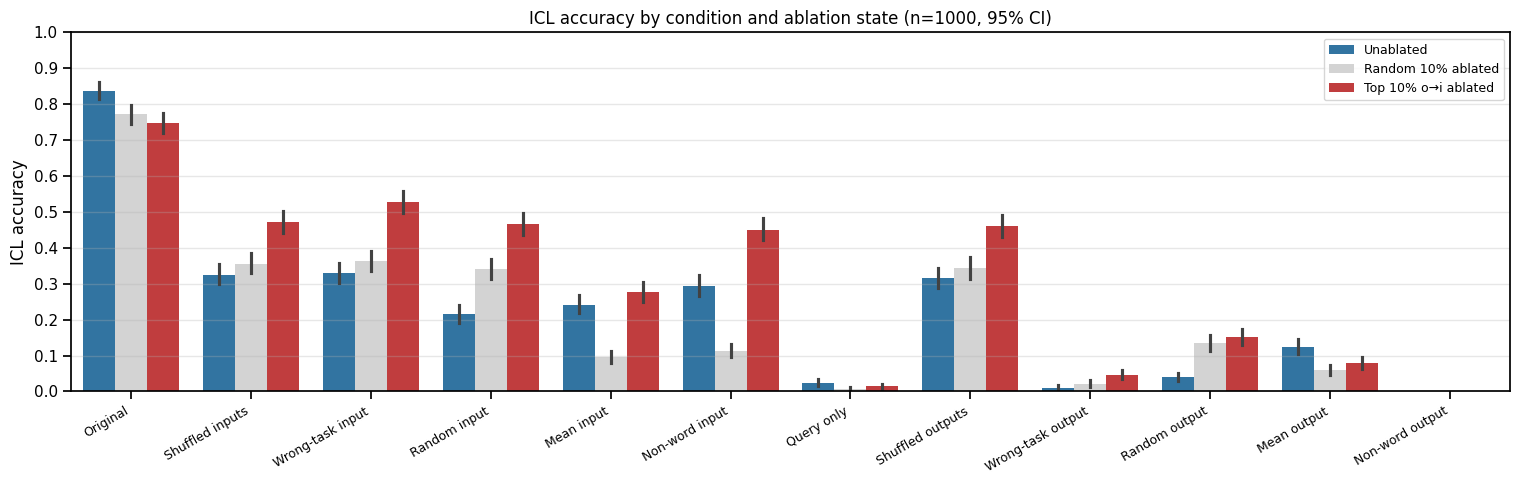

In [17]:
tick_map = {
    'orig':                     'Original',
    'shuffled':                 'Shuffled inputs',
    'wrong_task_inputs':        'Wrong-task input',
    'random_from_input_pool':   'Random input',
    'mean_embed':               'Mean input',
    'star':                     'Non-word input',
    'query_only':               'Query only',
    'shuffled_outputs':         'Shuffled outputs',
    'wrong_task_outputs':       'Wrong-task output',
    'random_from_output_pool':  'Random output',
    'mean_embed_outputs':       'Mean output',
    'star_outputs':             'Non-word output',
}
ab_label = {'unablated': 'Unablated', 'top10': 'Top 10% o→i ablated', 'rand10': 'Random 10% ablated'}
ab_palette = {'Unablated': 'tab:blue', 'Top 10% o→i ablated': 'tab:red', 'Random 10% ablated': 'lightgray'}

rows = []
for ab in ABL_KEYS:
    for c in ALL_CONDS:
        for v in results_correct[ab][c]:
            rows.append({'Condition': tick_map[c], 'Ablation': ab_label[ab], 'Correct': v})
df = pd.DataFrame(rows)

order_labels = [tick_map[c] for c in ALL_CONDS]
ab_order = ['Unablated', 'Random 10% ablated', 'Top 10% o→i ablated']

fig, ax = plt.subplots(figsize=(6.4*2.4, 5.0))
sns.barplot(data=df, x='Condition', y='Correct', hue='Ablation', order=order_labels,
            hue_order=ab_order, palette=ab_palette, errorbar=('ci', 95), linewidth=0, ax=ax)
ax.set_ylabel('ICL accuracy')
ax.set_xlabel('')
ax.set_ylim(0, 1.0)
ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.set_title(f'ICL accuracy by condition and ablation state (n={n_total}, 95% CI)')
ax.grid(True, alpha=0.3, axis='y')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
ax.legend(title='', loc='upper right', fontsize=9)
plt.tight_layout(); plt.show()

## Plot: rank per condition, three ablation states overlaid

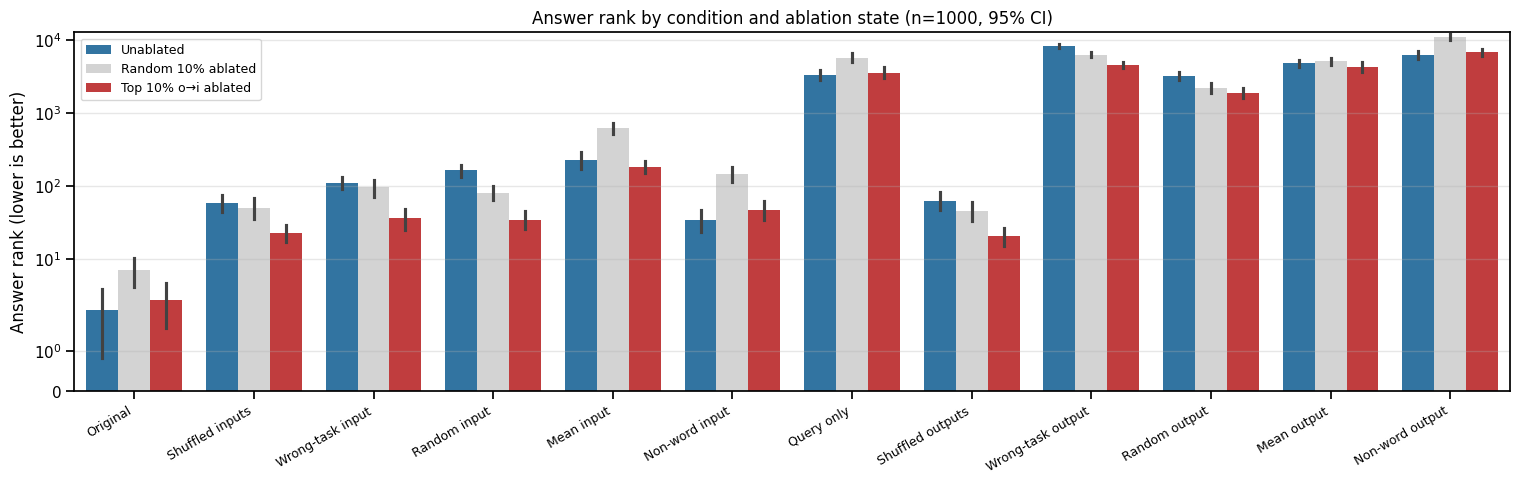

In [18]:
rows = []
for ab in ABL_KEYS:
    for c in ALL_CONDS:
        for v in results_rank[ab][c]:
            rows.append({'Condition': tick_map[c], 'Ablation': ab_label[ab], 'Rank': v})
df_r = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(6.4*2.4, 5.0))
sns.barplot(data=df_r, x='Condition', y='Rank', hue='Ablation', order=order_labels,
            hue_order=ab_order, palette=ab_palette, errorbar=('ci', 95), linewidth=0, ax=ax)
ax.set_ylabel('Answer rank (lower is better)')
ax.set_xlabel('')
ax.set_yscale('symlog')
ax.set_ylim(bottom=0)
ax.set_title(f'Answer rank by condition and ablation state (n={n_total}, 95% CI)')
ax.grid(True, alpha=0.3, axis='y')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
ax.legend(title='', loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()

## Per task

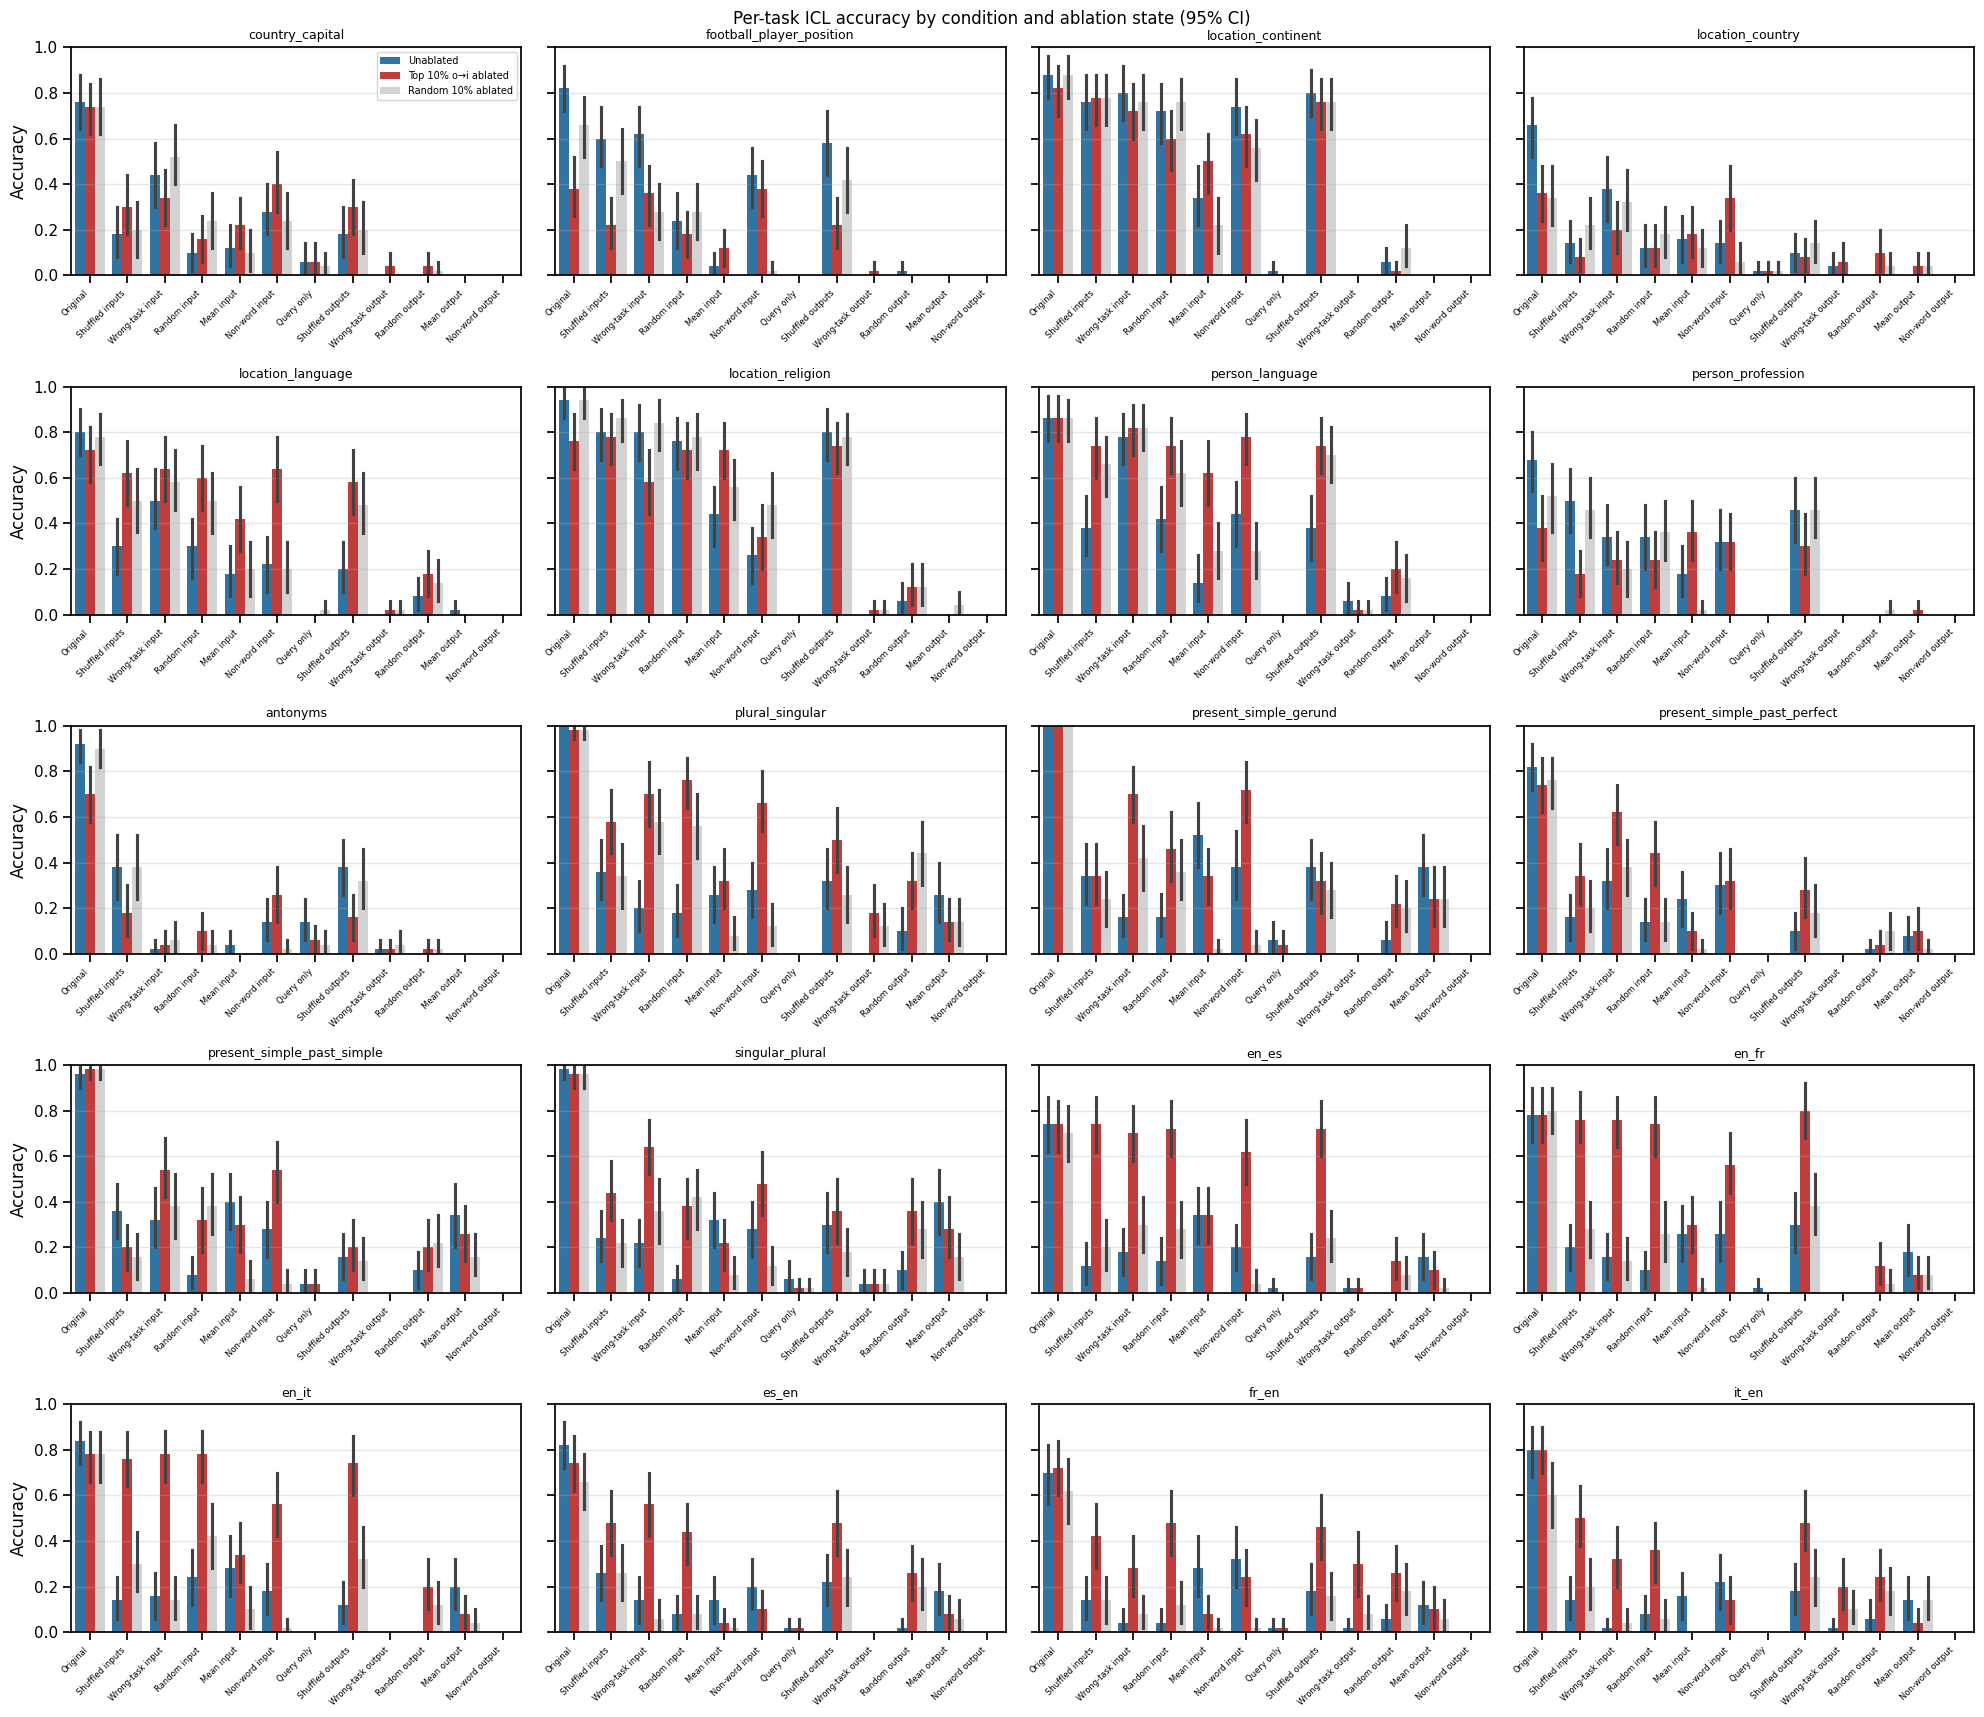

In [26]:
# Per-task accuracy plot
task_list_sorted = sorted(set(prompt_task_record))
n_cols = 4
n_rows = int(np.ceil(len(task_list_sorted) / n_cols))

# Local palette/order using whatever labels ab_label currently maps to
ab_order_local = [ab_label[k] for k in ['unablated', 'top10', 'rand10']]
ab_palette_local = {
    ab_label['unablated']: 'tab:blue',
    ab_label['top10']:     'tab:red',
    ab_label['rand10']:    'lightgray',
}

rows_acc_task = []
for ab in ABL_KEYS:
    for c in ALL_CONDS:
        for i, v in enumerate(results_correct[ab][c]):
            rows_acc_task.append({
                'Condition': tick_map[c],
                'Ablation': ab_label[ab],
                'Task': prompt_task_record[i],
                'Correct': v,
            })
df_acc_task = pd.DataFrame(rows_acc_task)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 3.5*n_rows), sharey=True)
axes = axes.flatten()

for ax, task in zip(axes, task_list_sorted):
    sub = df_acc_task[df_acc_task['Task'] == task]
    sns.barplot(data=sub, x='Condition', y='Correct', hue='Ablation',
                order=order_labels, hue_order=ab_order_local, palette=ab_palette_local,
                errorbar=('ci', 95), linewidth=0, ax=ax, legend=(ax is axes[0]))
    ax.set_title(task.split('/')[-1], fontsize=9)
    ax.set_ylim(0, 1.0)
    ax.set_xlabel('')
    ax.set_ylabel('Accuracy' if ax in axes[::n_cols] else '')
    ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=6)

axes[0].legend(title='', loc='upper right', fontsize=7)

for ax in axes[len(task_list_sorted):]:
    ax.set_visible(False)

fig.suptitle('Per-task ICL accuracy by condition and ablation state (95% CI)', fontsize=12)
plt.tight_layout(); plt.show()

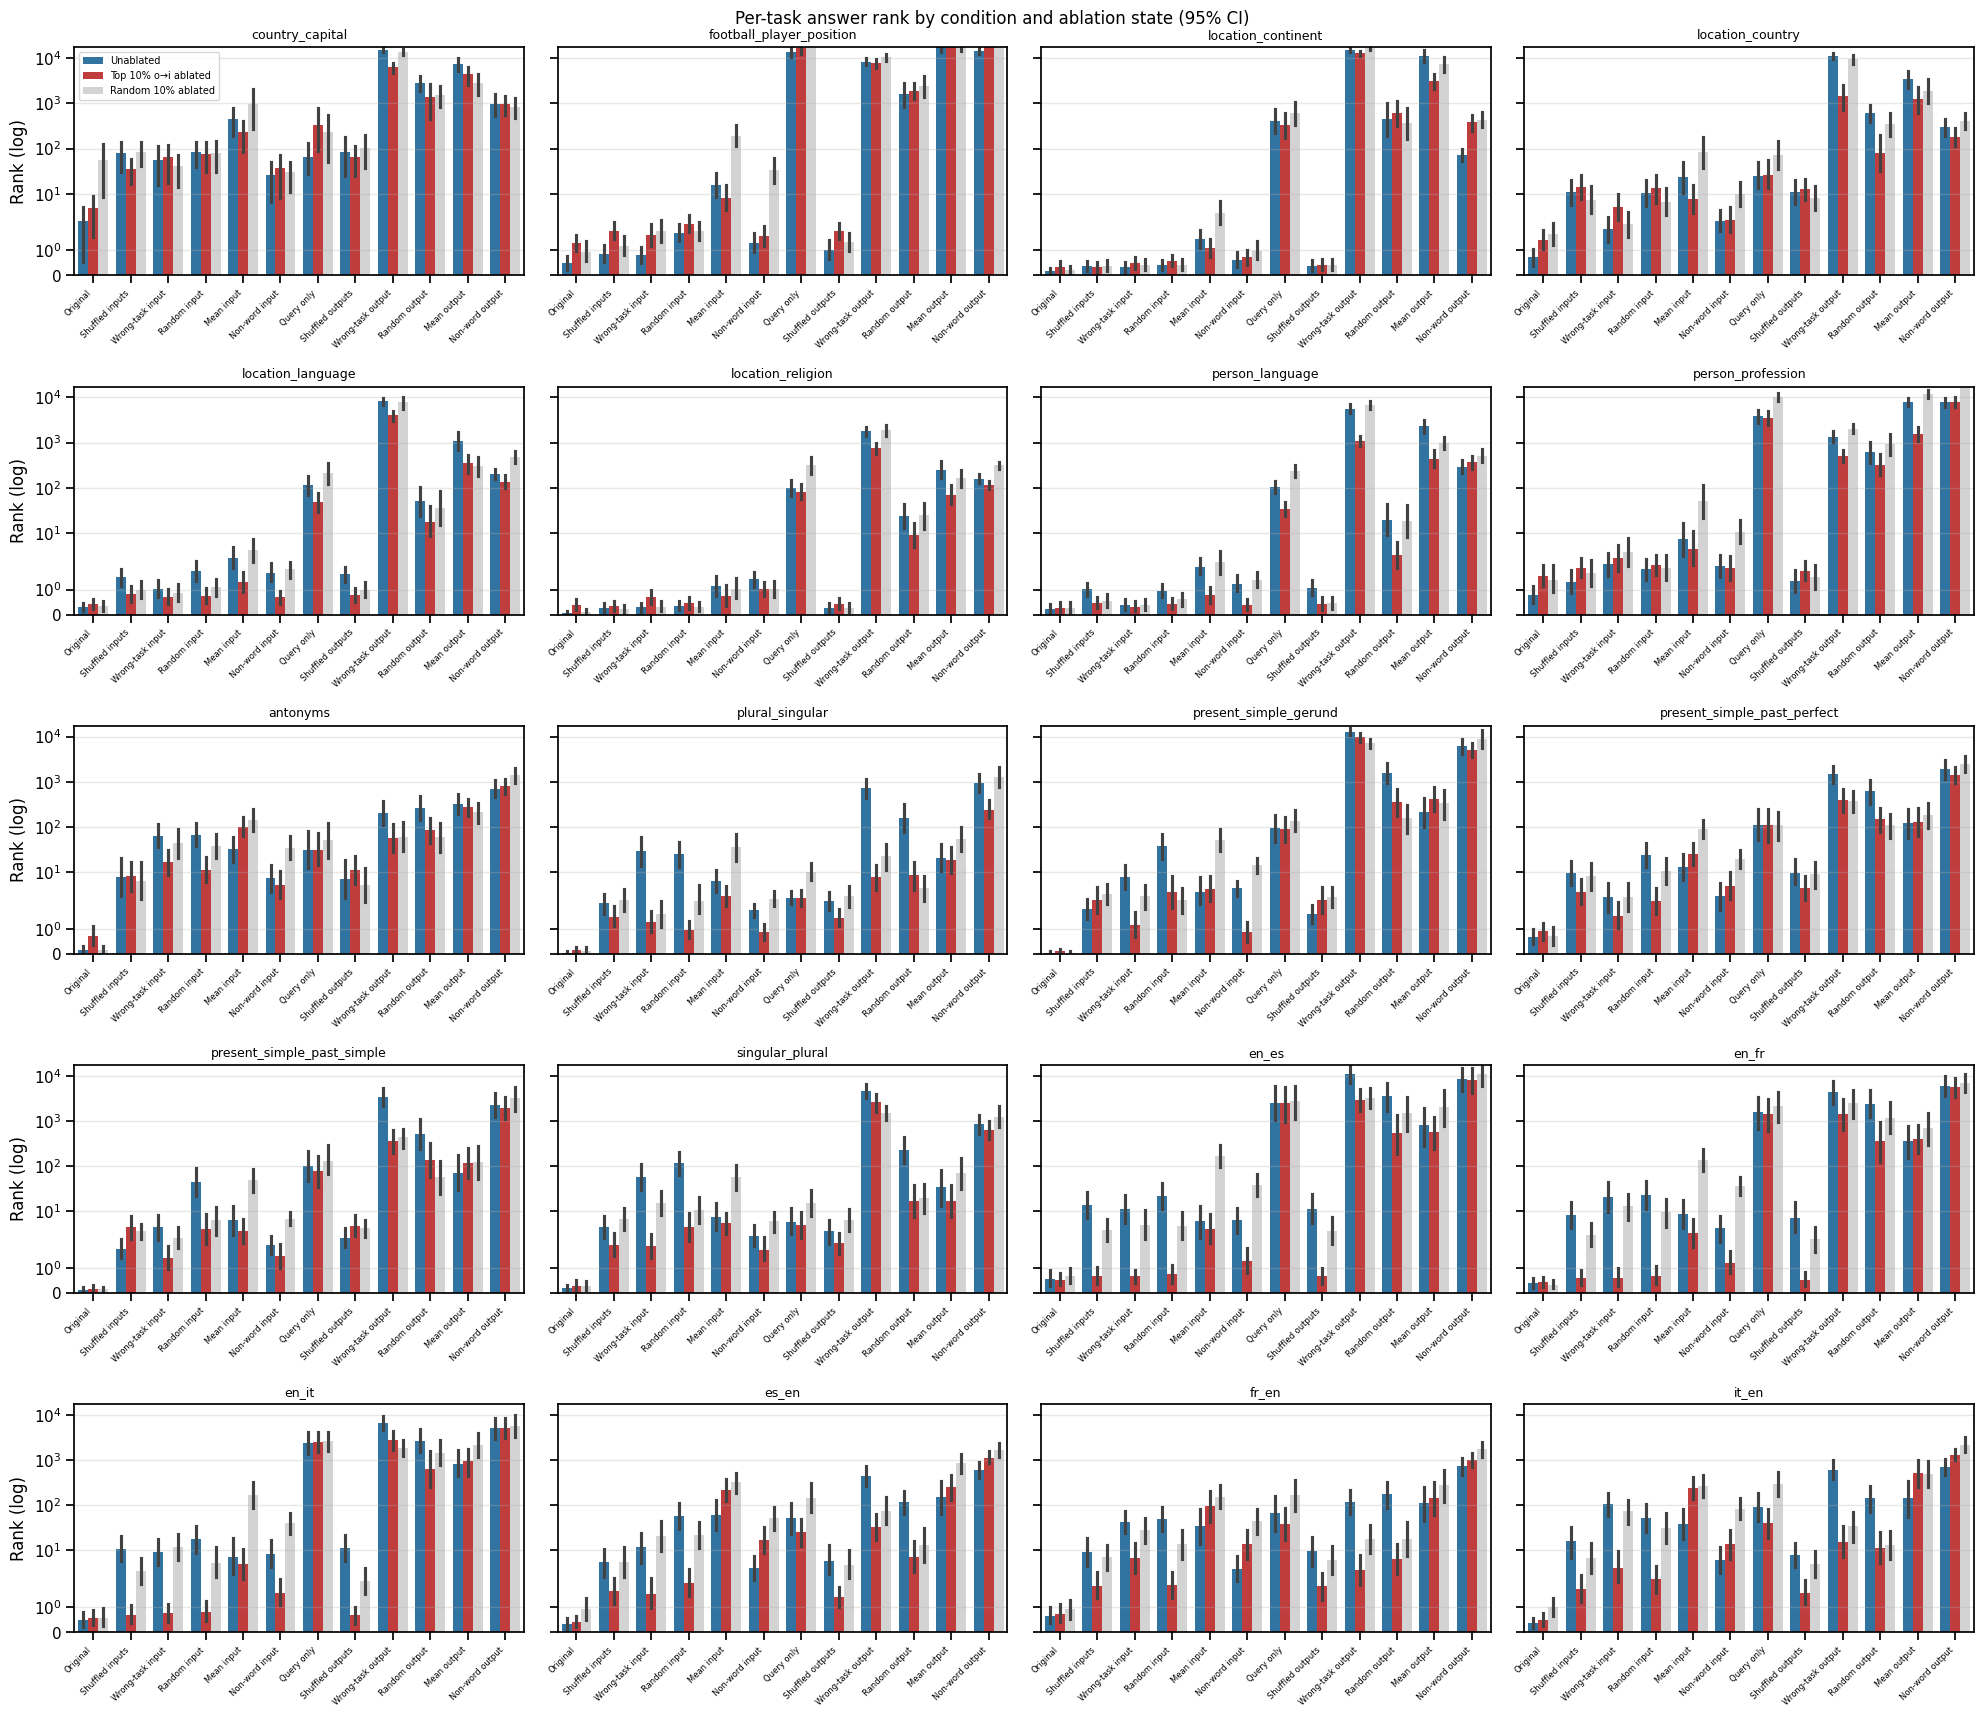

In [27]:
# Per-task rank plot
rows_rank_task = []
for ab in ABL_KEYS:
    for c in ALL_CONDS:
        for i, v in enumerate(results_rank[ab][c]):
            rows_rank_task.append({
                'Condition': tick_map[c],
                'Ablation': ab_label[ab],
                'Task': prompt_task_record[i],
                'Rank': v,
            })
df_rank_task = pd.DataFrame(rows_rank_task)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 3.5*n_rows), sharey=True)
axes = axes.flatten()

for ax, task in zip(axes, task_list_sorted):
    sub = df_rank_task[df_rank_task['Task'] == task]
    sns.barplot(data=sub, x='Condition', y='Rank', hue='Ablation',
                order=order_labels, hue_order=ab_order_local, palette=ab_palette_local,
                errorbar=('ci', 95), linewidth=0, ax=ax, legend=(ax is axes[0]))
    ax.set_title(task.split('/')[-1], fontsize=9)
    ax.set_yscale('symlog')
    ax.set_ylim(bottom=0)
    ax.set_xlabel('')
    ax.set_ylabel('Rank (log)' if ax in axes[::n_cols] else '')
    ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=6)

axes[0].legend(title='', loc='upper left', fontsize=7)

for ax in axes[len(task_list_sorted):]:
    ax.set_visible(False)

fig.suptitle('Per-task answer rank by condition and ablation state (95% CI)', fontsize=12)
plt.tight_layout(); plt.show()

## Marginal numbers table

In [19]:
def wilson(k, n, Z=1.96):
    if n == 0: return 0, 0, 0
    p = k / n
    denom = 1 + Z**2/n
    c = (p + Z**2/(2*n)) / denom
    h = Z * sqrt(p*(1-p)/n + Z**2/(4*n**2)) / denom
    return p, max(0, c-h), min(1, c+h)

print(f'{"Condition":<26} | {"Unablated":<22} | {"Top 10% o→i ablated":<22} | {"Random 10% ablated":<22}')
print('-' * 102)
for c in ALL_CONDS:
    parts = [f'{tick_map[c]:<26}']
    for ab in ABL_KEYS:
        p, lo, hi = wilson(results_correct[ab][c].sum(), n_total)
        parts.append(f' {p:>5.3f} [{lo:.3f}, {hi:.3f}]    ')
    print(' | '.join(parts))

Condition                  | Unablated              | Top 10% o→i ablated    | Random 10% ablated    
------------------------------------------------------------------------------------------------------
Original                   |  0.838 [0.814, 0.860]     |  0.747 [0.719, 0.773]     |  0.773 [0.746, 0.798]    
Shuffled inputs            |  0.325 [0.297, 0.355]     |  0.472 [0.441, 0.503]     |  0.355 [0.326, 0.385]    
Wrong-task input           |  0.330 [0.302, 0.360]     |  0.527 [0.496, 0.558]     |  0.363 [0.334, 0.393]    
Random input               |  0.215 [0.191, 0.242]     |  0.467 [0.436, 0.498]     |  0.342 [0.313, 0.372]    
Mean input                 |  0.242 [0.216, 0.270]     |  0.276 [0.249, 0.305]     |  0.096 [0.079, 0.116]    
Non-word input             |  0.294 [0.267, 0.323]     |  0.451 [0.420, 0.482]     |  0.113 [0.095, 0.134]    
Query only                 |  0.024 [0.016, 0.035]     |  0.014 [0.008, 0.023]     |  0.007 [0.003, 0.014]    
Shuffled outputs  

## Using the non-subtraction original definition

In [20]:
# Score using the ORIGINAL definition: avg attention from output queries to within-demo input keys.
# No baseline subtraction. This reproduces the "all-output method" from earlier work.
oi_score_orig_sum = np.zeros((n_layers, n_heads), dtype=np.float64)
oi_score_orig_cnt = 0
PATTERN_FILTER = lambda name: 'attn.hook_pattern' in name

scoring_jobs = [(t, splits, p_idx, pdata)
                for t, splits in all_splits.items()
                for p_idx, pdata in enumerate(splits['icl_prompts'])]

for t, splits, p_idx, pdata in tqdm(scoring_jobs, desc='Scoring (original def)'):
    demos = pdata['demo_pairs']
    tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
    seq_len = tokens.shape[1]
    per_demo = find_per_demo_positions(model, pdata['prompt'], demos)
    
    num_mask = torch.zeros(seq_len, seq_len)
    for d in per_demo:
        ins  = d.get('input_positions', [])
        outs = d.get('output_positions', [])
        for op in outs:
            for ip in ins:
                num_mask[op, ip] = 1.0
    n_num_pairs = int(num_mask.sum().item())
    if n_num_pairs == 0: continue
    
    with torch.no_grad():
        _, cache = model.run_with_cache(tokens, names_filter=PATTERN_FILTER)
    
    for L in range(n_layers):
        patt = cache['pattern', L][0].cpu().float()  # [n_heads, seq, seq]
        num_per_head = (patt * num_mask).sum(dim=(1, 2)).numpy() / n_num_pairs
        oi_score_orig_sum[L, :] += num_per_head
    
    oi_score_orig_cnt += 1
    del cache
    torch.cuda.empty_cache()

oi_score_orig = oi_score_orig_sum / max(oi_score_orig_cnt, 1)

flat_orig = [(L, h, oi_score_orig[L, h]) for L in range(n_layers) for h in range(n_heads)]
flat_orig.sort(key=lambda x: -x[2])
top10pct_n_orig = max(1, int(0.10 * len(flat_orig)))
top10_heads_orig = [(L, h) for L, h, s in flat_orig[:top10pct_n_orig]]

_rng_o = random.Random(0)
all_pairs = [(L, h) for L in range(n_layers) for h in range(n_heads)]
top10_set_orig = set(top10_heads_orig)
rand10_heads_orig = _rng_o.sample([p for p in all_pairs if p not in top10_set_orig], top10pct_n_orig)

print(f'Scored {oi_score_orig_cnt} prompts')
print(f'Top 10 heads by ORIGINAL output→input score (no baseline subtraction):')
for L, h, s in flat_orig[:10]:
    print(f'  L{L:2d}H{h:2d}: {s:.4f}')

Scoring (original def): 100%|██████████| 1000/1000 [02:06<00:00,  7.90it/s]

Scored 1000 prompts
Top 10 heads by ORIGINAL output→input score (no baseline subtraction):
  L 5H 3: 0.2002
  L10H10: 0.1700
  L 4H14: 0.1407
  L 7H 7: 0.1296
  L13H13: 0.1287
  L 7H18: 0.1254
  L 7H20: 0.1117
  L 7H19: 0.1082
  L13H 9: 0.1074
  L12H 1: 0.1072


In [21]:
# Build ablation hooks for the original-score-selected heads
ablation_hooks_top10_orig  = make_ablation_hooks(heads_by_layer_from(top10_heads_orig))
ablation_hooks_rand10_orig = make_ablation_hooks(heads_by_layer_from(rand10_heads_orig))

print(f'Built ablation hooks: top {top10pct_n_orig} (original score) + matched random {top10pct_n_orig}')

Built ablation hooks: top 67 (original score) + matched random 67


In [22]:
# Test: orig-condition ICL accuracy and rank under three ablation states (1000 prompts)
orig_results_correct = {'unablated': [], 'top10': [], 'rand10': []}
orig_results_rank    = {'unablated': [], 'top10': [], 'rand10': []}
orig_hook_sets = {
    'unablated': [],
    'top10':  ablation_hooks_top10_orig,
    'rand10': ablation_hooks_rand10_orig,
}

orig_jobs = [(t, splits, p_idx, pdata)
             for t, splits in all_splits.items()
             for p_idx, pdata in enumerate(splits['icl_prompts'])]

for t, splits, p_idx, pdata in tqdm(orig_jobs, desc='Orig-only eval'):
    ans = pdata.get('query_output')
    if ans is None: continue
    tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
    last = tokens.shape[1] - 1
    
    for ab_key, ab_hooks in orig_hook_sets.items():
        with torch.no_grad():
            if ab_hooks:
                logits = model.run_with_hooks(tokens, fwd_hooks=ab_hooks)[0, last]
            else:
                logits = model(tokens)[0, last]
        orig_results_correct[ab_key].append(int(check_correct(model, logits, ans)))
        orig_results_rank[ab_key].append(answer_rank(model, logits, ans))
    
    torch.cuda.empty_cache()

for ab_key in orig_hook_sets:
    orig_results_correct[ab_key] = np.array(orig_results_correct[ab_key])
    orig_results_rank[ab_key]    = np.array(orig_results_rank[ab_key])

n_orig = len(orig_results_correct['unablated'])
print(f'\nTotal prompts: {n_orig}')
print(f'\n{"State":<12} {"Accuracy":>10}  {"Mean rank":>12}')
print('-' * 36)
for ab_key in ['unablated', 'top10', 'rand10']:
    acc = orig_results_correct[ab_key].mean()
    rank = orig_results_rank[ab_key].mean()
    label = {'unablated': 'Unablated', 'top10': 'Top 10%', 'rand10': 'Random 10%'}[ab_key]
    print(f'{label:<12} {acc:>10.3f}  {rank:>12.2f}')

Orig-only eval: 100%|██████████| 1000/1000 [03:20<00:00,  4.98it/s]


Total prompts: 1000

State          Accuracy     Mean rank
------------------------------------
Unablated         0.838          2.00
Top 10%           0.756          3.12
Random 10%        0.749          5.91


/tmp/ipykernel_2060564/1049649056.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_acc, x='Ablation', y='Correct', order=ab_order,
/tmp/ipykernel_2060564/1049649056.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_rank, x='Ablation', y='Rank', order=ab_order,


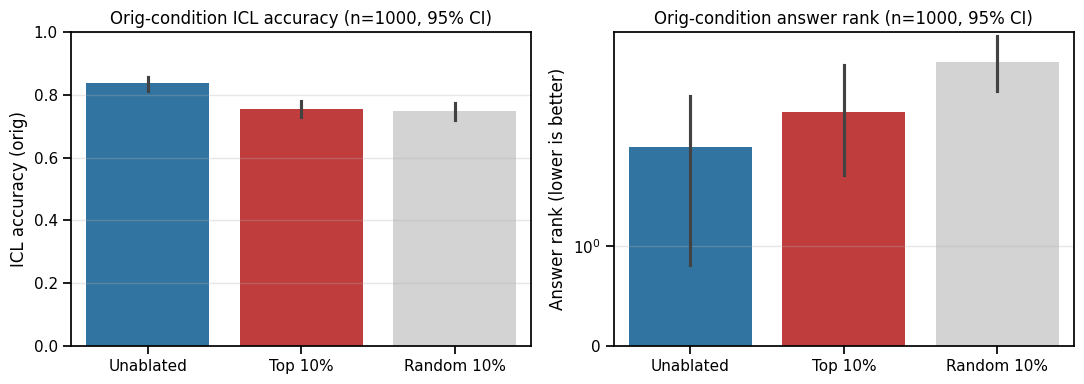

In [23]:
# Plot the orig-only comparison
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ab_order = ['Unablated', 'Top 10%', 'Random 10%']
ab_colors = {'Unablated': 'tab:blue', 'Top 10%': 'tab:red', 'Random 10%': 'lightgray'}
key_to_label = {'unablated': 'Unablated', 'top10': 'Top 10%', 'rand10': 'Random 10%'}

df_acc = pd.DataFrame({
    'Ablation': np.concatenate([[key_to_label[k]] * n_orig for k in ['unablated', 'top10', 'rand10']]),
    'Correct':  np.concatenate([orig_results_correct[k] for k in ['unablated', 'top10', 'rand10']]),
})
sns.barplot(data=df_acc, x='Ablation', y='Correct', order=ab_order,
            palette=[ab_colors[a] for a in ab_order], errorbar=('ci', 95), ax=axes[0])
axes[0].set_ylabel('ICL accuracy (orig)')
axes[0].set_xlabel('')
axes[0].set_ylim(0, 1.0)
axes[0].set_title(f'Orig-condition ICL accuracy (n={n_orig}, 95% CI)')
axes[0].grid(True, alpha=0.3, axis='y')

df_rank = pd.DataFrame({
    'Ablation': np.concatenate([[key_to_label[k]] * n_orig for k in ['unablated', 'top10', 'rand10']]),
    'Rank':     np.concatenate([orig_results_rank[k] for k in ['unablated', 'top10', 'rand10']]),
})
sns.barplot(data=df_rank, x='Ablation', y='Rank', order=ab_order,
            palette=[ab_colors[a] for a in ab_order], errorbar=('ci', 95), ax=axes[1])
axes[1].set_ylabel('Answer rank (lower is better)')
axes[1].set_xlabel('')
axes[1].set_yscale('symlog')
axes[1].set_title(f'Orig-condition answer rank (n={n_orig}, 95% CI)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

Top 67 heads each (10% of 672)
Overlap:                  62 / 67  (92.5%)
Only in baseline-sub:      5
Only in original:          5


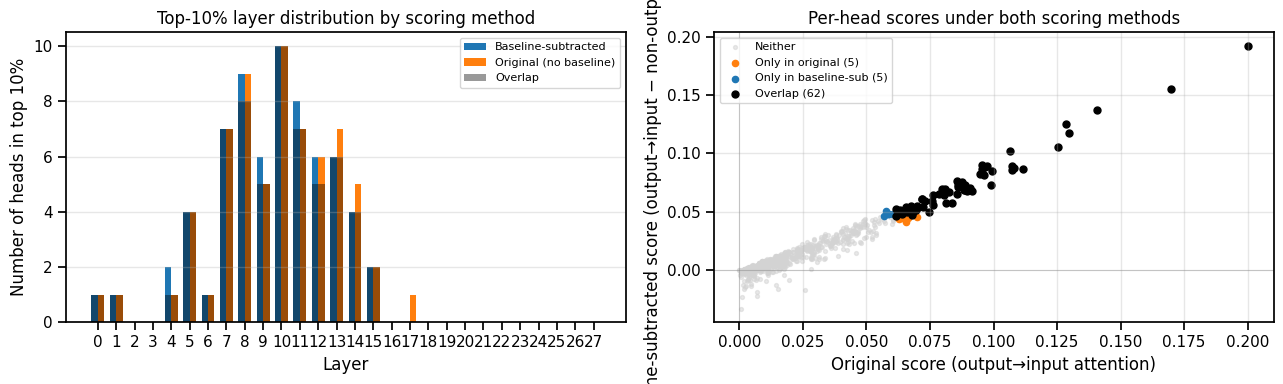


Heads ONLY in original-score top 10% (high output→input attention but not selective):
  L14H 8: orig_score=0.0699, baseline_sub_score=+0.0453
  L13H18: orig_score=0.0663, baseline_sub_score=+0.0445
  L12H12: orig_score=0.0654, baseline_sub_score=+0.0411
  L17H15: orig_score=0.0641, baseline_sub_score=+0.0446
  L 8H14: orig_score=0.0628, baseline_sub_score=+0.0436

Heads ONLY in baseline-subtracted top 10% (selectively output→input):
  L 8H10: baseline_sub_score=+0.0507, orig_score=0.0579
  L 4H 6: baseline_sub_score=+0.0485, orig_score=0.0586
  L11H19: baseline_sub_score=+0.0478, orig_score=0.0587
  L 9H 1: baseline_sub_score=+0.0478, orig_score=0.0606
  L12H 9: baseline_sub_score=+0.0468, orig_score=0.0568


In [24]:
top10_set_baseline = set(top10_heads)        # baseline-subtracted score
top10_set_original = set(top10_heads_orig)   # original score (no baseline)

overlap     = top10_set_baseline & top10_set_original
only_base   = top10_set_baseline - top10_set_original
only_orig   = top10_set_original - top10_set_baseline

n_top = len(top10_set_baseline)
print(f'Top {n_top} heads each (10% of {n_layers * n_heads})')
print(f'Overlap:                {len(overlap):>4} / {n_top}  ({100*len(overlap)/n_top:.1f}%)')
print(f'Only in baseline-sub:   {len(only_base):>4}')
print(f'Only in original:       {len(only_orig):>4}')

# Layer distributions
def layer_hist(head_set):
    counts = np.zeros(n_layers, dtype=int)
    for L, _ in head_set:
        counts[L] += 1
    return counts

hist_base = layer_hist(top10_set_baseline)
hist_orig = layer_hist(top10_set_original)
hist_overlap = layer_hist(overlap)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: layer histograms of the two top sets
x = np.arange(n_layers)
w = 0.35
axes[0].bar(x - w/2, hist_base, w, label='Baseline-subtracted', color='tab:blue')
axes[0].bar(x + w/2, hist_orig, w, label='Original (no baseline)', color='tab:orange')
axes[0].bar(x - w/2, hist_overlap, w, color='black', alpha=0.4, label='Overlap')
axes[0].bar(x + w/2, hist_overlap, w, color='black', alpha=0.4)
axes[0].set_xlabel('Layer')
axes[0].set_ylabel(f'Number of heads in top 10%')
axes[0].set_title(f'Top-10% layer distribution by scoring method')
axes[0].set_xticks(x)
axes[0].legend(loc='upper right', fontsize=8)
axes[0].grid(True, alpha=0.3, axis='y')

# Right: scatter of original vs baseline-sub score, all heads, with top-10% in each method colored
all_x = oi_score_orig.flatten()
all_y = oi_score.flatten()  # baseline-subtracted

# Mark categories
in_overlap = np.zeros((n_layers, n_heads), dtype=bool)
in_only_base = np.zeros((n_layers, n_heads), dtype=bool)
in_only_orig = np.zeros((n_layers, n_heads), dtype=bool)
for L, h in overlap: in_overlap[L, h] = True
for L, h in only_base: in_only_base[L, h] = True
for L, h in only_orig: in_only_orig[L, h] = True

ax = axes[1]
neither = ~(in_overlap | in_only_base | in_only_orig)
ax.scatter(all_x[neither.flatten()], all_y[neither.flatten()], s=8, c='lightgray', alpha=0.5, label='Neither')
ax.scatter(all_x[in_only_orig.flatten()], all_y[in_only_orig.flatten()], s=20, c='tab:orange',
           label=f'Only in original ({len(only_orig)})')
ax.scatter(all_x[in_only_base.flatten()], all_y[in_only_base.flatten()], s=20, c='tab:blue',
           label=f'Only in baseline-sub ({len(only_base)})')
ax.scatter(all_x[in_overlap.flatten()], all_y[in_overlap.flatten()], s=25, c='black',
           label=f'Overlap ({len(overlap)})')

ax.set_xlabel('Original score (output→input attention)')
ax.set_ylabel('Baseline-subtracted score (output→input − non-output→input)')
ax.set_title('Per-head scores under both scoring methods')
ax.axhline(0, color='gray', alpha=0.5, lw=0.5)
ax.axvline(0, color='gray', alpha=0.5, lw=0.5)
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# Print the heads that differ between methods
print(f'\nHeads ONLY in original-score top 10% (high output→input attention but not selective):')
for L, h in sorted(only_orig, key=lambda lh: -oi_score_orig[lh[0], lh[1]])[:15]:
    print(f'  L{L:2d}H{h:2d}: orig_score={oi_score_orig[L, h]:.4f}, baseline_sub_score={oi_score[L, h]:+.4f}')

print(f'\nHeads ONLY in baseline-subtracted top 10% (selectively output→input):')
for L, h in sorted(only_base, key=lambda lh: -oi_score[lh[0], lh[1]])[:15]:
    print(f'  L{L:2d}H{h:2d}: baseline_sub_score={oi_score[L, h]:+.4f}, orig_score={oi_score_orig[L, h]:.4f}')